# Trading Strategy Assignment: Exploratory Data Analysis and Strategy Optimization

## Overview

This assignment explores the intersection of **technical analysis**, **natural language processing**, and **large-scale data processing** in the context of algorithmic trading. You will work with historical market data and earnings call transcripts to develop and evaluate trading strategies.

### Learning Objectives

- **Technical Analysis**: Implement and analyze technical indicators (Moving Averages, RSI, MACD, Bollinger Bands)
- **NLP for Finance**: Apply FinBERT (a financial BERT model) for sentiment analysis on earnings transcripts
- **Scalable Computing**: Explore parallelization techniques for computing indicators on large datasets—consider approaches that can reduce latency compared to iterative pandas operations
- **Strategy Development**: Systematically improve a baseline strategy through iterative experimentation
- **Performance Evaluation**: Use proper train/validation split methodology for model development

---

## Data Description

### Price Data
S&P 500 historical price data with the following schema:

| Column | Description |
|--------|-------------|
| `ticker` | Stock symbol (e.g., AAPL, MSFT) |
| `date` | Trading date |
| `open`, `high`, `low`, `close` | OHLC prices |
| `volume` | Trading volume |

### Earnings Data
Earnings call transcripts for sentiment analysis:

| Column | Description |
|--------|-------------|
| `ticker` | Stock symbol |
| `date` | Earnings call date |
| `transcript` | Full text of earnings call |
| `quarter` | Fiscal quarter (e.g., "Q1 2023") |

---

## Data Splits

The data is partitioned to enable proper model development:

| Split | Date Range | Purpose |
|-------|------------|---------|
| **Dev** | 2000-2017 | Create subsets for development and hyperparameter tuning |
| **Val** | 2018-2024 | Final performance reporting (unseen during development) |

**Important**: Use the dev split and create subsets to iterate and experiment. Reserve the val split for final performance reporting only.

---

## Provided Infrastructure

### Baseline Strategy
A simple moving average crossover strategy enhanced with FinBERT sentiment:
- **Entry**: Price > MA-50 AND (no earnings OR positive sentiment)
- **Exit**: Price < MA-50 OR stop-loss at 20%

### Evaluation Framework
Weekly rebalancing backtest simulation with the following metrics:

| Metric | Description | Target |
|--------|-------------|--------|
| **Total Return** | Portfolio value change from starting capital | Maximize |
| **Sharpe Ratio** | Risk-adjusted return (higher is better) | >1.0 is good |
| **Max Drawdown** | Largest peak-to-trough decline | Minimize |
| **Win Rate** | Percentage of profitable trades | >40% |
| **Volatility** | Standard deviation of returns | Lower for same return |

### Visualization Tools
- Portfolio value over time
- Drawdown analysis
- Returns distribution
- Rolling returns
- Comparison charts

---

## Assignment Workflow

1. **Run cells 1-10** to establish baseline performance
2. **Perform advanced EDA** to understand the data
3. **Implement improvements** in `EnhancedStrategy` (Cell 12) across these areas:
   - Data Quality & Cleaning
   - Technical Indicators
   - Enhanced NLP Analysis
   - Smarter Decision Logic
4. **Iterate based on subsets created in dev split** to tune your strategy
5. **Report final performance** on val split when satisfied

---

## Expected Outcomes

By the end of this assignment, you should have:

1. **Implemented** an enhanced trading strategy that improves upon the baseline
2. **Demonstrated** understanding of scalable computing for large-scale data processing
3. **Documented** your development process and key findings
4. **Achieved** measurable improvements in key metrics (Return, Sharpe, Drawdown)

## GPU Configuration (Optional)

**Important:** You can configure your runtime to use GPU acceleration before executing any cells. GPU acceleration provides 3-4x faster inference for the FinBERT model.

### Configuration Steps

Navigate to **Runtime → Change runtime type → Hardware accelerator: T4 GPU → Save**

### Verification

The first cell has print statement that informs the hardware being used

In [2]:
#%pip uninstall torch torchvision torchaudio -y
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#%pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#%pip install torch>=2.6.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
import os
# This bypasses the specific security check that is blocking your version of Torch
os.environ["TRANSFORMERS_VERIFY_SCHEDULED_REMOVAL"] = "False"

import pandas as pd
import numpy as np
import time
import warnings
from datetime import timedelta
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
import torch



# ============================================================
# LOCAL SETUP
# ============================================================
# Replaced Google Drive mount with your local folder
DATA_DIR = Path('./sample_data') 
print(torch.__version__)

warnings.filterwarnings('ignore')

# Configuration
STARTING_CASH = 100000
FINBERT_MODEL = "ProsusAI/finbert"
# In local environments, device 0 is GPU, -1 is CPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current Device: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Initial capital: ${STARTING_CASH:,.0f}")
print(f"Device: {'GPU' if DEVICE >= 0 else 'CPU'}")

# ============================================================
# INITIALIZE FINBERT
# ============================================================
print("Loading FinBERT...")

# SOLUTION: Force safetensors loading to bypass torch version check
# This avoids CVE-2025-32434 without upgrading torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(
    FINBERT_MODEL,
    use_safetensors=True  # Force safetensors format
)

if DEVICE >= 0:
    model = model.to('cuda')

finbert_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=512
)

print(f"FinBERT loaded on {torch.cuda.get_device_name(0) if DEVICE >= 0 else 'CPU'}.")

# ============================================================
# DATA LOADING
# ============================================================
def load_prices(split='dev'):
    filepath = DATA_DIR / f'prices_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}. Ensure files are in the 'sample_data' folder.")
    return pd.read_parquet(filepath)

def load_earnings(split='dev'):
    filepath = DATA_DIR / f'earnings_{split}.parquet'
    if not filepath.exists():
        raise FileNotFoundError(f"Not found: {filepath}")
    return pd.read_parquet(filepath)

# Load the data
prices_dev = load_prices('dev')
prices_val = load_prices('val')
earnings_dev = load_earnings('dev')
earnings_val = load_earnings('val')

print(f"Dev prices:   {len(prices_dev):,} records")
print(f"Val prices:   {len(prices_val):,} records")
print(f"Dev earnings: {len(earnings_dev):,} records")
print(f"Val earnings: {len(earnings_val):,} records")

c:\Users\Max\anaconda3\envs\Max-OpenCV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.5.1+cu121
CUDA Available: True
Current Device: NVIDIA GeForce RTX 4080
Memory Allocated: 0.00 MB
Initial capital: $100,000
Device: GPU
Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4841.61it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded on NVIDIA GeForce RTX 4080.
Dev prices:   1,332,576 records
Val prices:   598,740 records
Dev earnings: 9,729 records
Val earnings: 8,534 records


In [3]:
# ============================================================
# CELL 4: Exploratory Data Analysis
# ============================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# --- Section 1: Price Data Overview ---
# Displays the timeframe covered by the dataset and the number of stocks (tickers) included.
print(f"\n[PRICE DATA]")
print(f"Date range: {prices_dev['date'].min()} to {prices_dev['date'].max()}")
print(f"Unique tickers: {prices_dev['ticker'].nunique()}")

# Generates summary statistics (mean, std dev, min/max) for the OHLCV columns.
# This helps identify scale and potential outliers in stock prices.
print(f"\nPrice statistics:")
print(prices_dev[['open', 'high', 'low', 'close', 'volume']].describe())

# --- Section 2: Data Integrity Check ---
# Checks for 'NaN' or null values across all columns. 
# Missing values in 'close' or 'date' can break backtesting logic.
print(f"\n[MISSING VALUES]")
print(prices_dev.isnull().sum())

# --- Section 3: Earnings Transcripts Overview ---
# Validates the metadata for the NLP component of the project.
print(f"\n[EARNINGS DATA]")
print(f"Date range: {earnings_dev['date'].min()} to {earnings_dev['date'].max()}")
print(f"Unique tickers: {earnings_dev['ticker'].nunique()}")

# Calculates the character count for each transcript.
# This is crucial because FinBERT has a 512-token limit (truncation=True is used in your setup).
earnings_dev['transcript_length'] = earnings_dev['transcript'].str.len()
print(f"\nTranscript lengths:")
print(earnings_dev['transcript_length'].describe())

# --- Section 4: Dataset Intersection ---
# Identifies which companies exist in both the price file AND the earnings file.
# Since your strategy relies on combining technicals with sentiment, you can 
# only trade tickers that appear in both (the "Overlap").
price_tickers = set(prices_dev['ticker'].unique())
earnings_tickers = set(earnings_dev['ticker'].unique())
overlap = price_tickers & earnings_tickers
print(f"\n[TICKER OVERLAP]")
print(f"Prices: {len(price_tickers)}, Earnings: {len(earnings_tickers)}, Overlap: {len(overlap)}")

print("="*60)

EXPLORATORY DATA ANALYSIS

[PRICE DATA]
Date range: 2000-01-03 00:00:00-05:00 to 2017-12-29 00:00:00-05:00
Unique tickers: 340

Price statistics:
               open          high           low         close        volume
count  1.332576e+06  1.332576e+06  1.332576e+06  1.332576e+06  1.332576e+06
mean   3.903053e+01  3.950141e+01  3.854264e+01  3.903509e+01  9.345944e+06
std    7.973711e+01  8.078698e+01  7.858469e+01  7.969384e+01  6.199364e+07
min    3.020800e-02  3.052100e-02  2.697900e-02  3.052100e-02  0.000000e+00
25%    1.247500e+01  1.265784e+01  1.228867e+01  1.247801e+01  8.168000e+05
50%    2.318565e+01  2.348415e+01  2.288000e+01  2.319054e+01  2.067218e+06
75%    4.215672e+01  4.263462e+01  4.168111e+01  4.217284e+01  5.068012e+06
max    2.136094e+03  2.160873e+03  2.097645e+03  2.126268e+03  9.230856e+09

[MISSING VALUES]
ticker    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

[EARNINGS DATA]
Date range: 2005-10-13 14:45:00 to 201

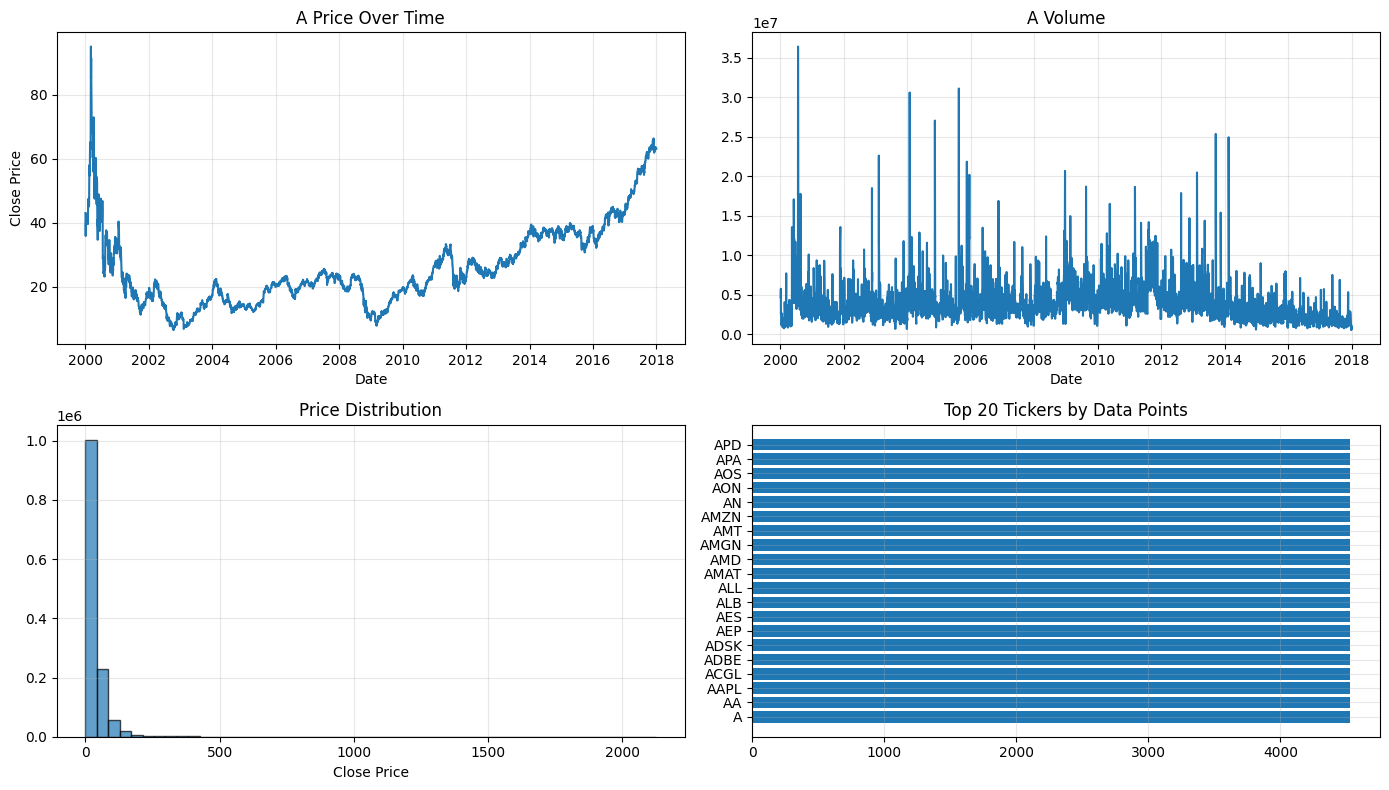

In [4]:
# ============================================================
# CELL 5: Data Visualization
# ============================================================

sample_ticker = prices_dev['ticker'].value_counts().index[0]
sample_prices = prices_dev[prices_dev['ticker'] == sample_ticker].sort_values('date')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(pd.to_datetime(sample_prices['date']), sample_prices['close'])
axes[0, 0].set_title(f'{sample_ticker} Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Close Price')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(pd.to_datetime(sample_prices['date']), sample_prices['volume'])
axes[0, 1].set_title(f'{sample_ticker} Volume')
axes[0, 1].set_xlabel('Date')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(prices_dev['close'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Price Distribution')
axes[1, 0].set_xlabel('Close Price')
axes[1, 0].grid(True, alpha=0.3)

ticker_counts = prices_dev['ticker'].value_counts().head(20)
axes[1, 1].barh(range(len(ticker_counts)), ticker_counts.values)
axes[1, 1].set_yticks(range(len(ticker_counts)))
axes[1, 1].set_yticklabels(ticker_counts.index)
axes[1, 1].set_title('Top 20 Tickers by Data Points')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Infrastructure

The following classes provide the foundation. You can extend or modify these as you explore.

---

## How the Backtest Simulation Works

### Weekly Rebalancing

The simulation implements a **weekly rebalancing** strategy:

1. **Every Friday**, the strategy evaluates all 400+ S&P 500 stocks
2. For each stock, the strategy makes a decision: `BUY`, `SELL`, or `HOLD`
3. The portfolio is rebalanced based on these decisions
4. Portfolio value and positions are tracked weekly

### Role of Earnings Calls

Earnings call transcripts provide **qualitative sentiment** that complements technical indicators:

| Data Source | Type | Example Signal |
|-------------|------|---------------|
| **Price/Technical** | Quantitative | Price > MA-50 (bullish trend) |
| **Earnings Transcript** | Qualitative | Management sounds confident about Q4 guidance (positive sentiment) |

**FinBERT** (Financial BERT) analyzes earnings transcripts to classify sentiment:
- **Positive**: Management upbeat, strong guidance, growth opportunities
- **Negative**: Cautionary language, cost-cutting, headwinds
- **Neutral**: Factual reporting, balanced outlook

**Example Usage in Strategy:**
```python
# Entry: Price in uptrend AND positive (or no) earnings sentiment
if price > ma_50 and (sentiment == 'positive' or sentiment is None):
    return 'BUY'

# Exit: Price in downtrend OR negative earnings sentiment
if price < ma_50 or sentiment == 'negative':
    return 'SELL'
```


In [5]:
# ============================================================
# CELL 6: Portfolio Class
# ============================================================

class Portfolio:
    def __init__(self, starting_cash=100000):
        self.cash = starting_cash
        self.positions = {}
        self.trades = []

    def buy_target(self, ticker, price, date, target_value=5000):
        if ticker in self.positions:
            return 0
        max_shares = int(target_value // price)
        if max_shares <= 0:
            return 0
        cost = min(max_shares * price, self.cash)
        shares = int(cost // price)
        if shares <= 0:
            return 0
        self.cash -= cost
        self.positions[ticker] = {'shares': shares, 'buy_price': price}
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'BUY',
                          'shares': shares, 'price': price, 'value': cost})
        return shares

    def sell(self, ticker, price, date):
        if ticker not in self.positions:
            return 0
        position = self.positions[ticker]
        shares = position['shares']
        proceeds = shares * price
        del self.positions[ticker]
        self.cash += proceeds
        self.trades.append({'date': date, 'ticker': ticker, 'action': 'SELL',
                          'shares': shares, 'price': price, 'value': proceeds})
        return shares

    def get_value(self, current_prices):
        total = self.cash
        for ticker, pos in self.positions.items():
            if ticker in current_prices:
                total += pos['shares'] * current_prices[ticker]
        return total

    def get_state(self, current_prices):
        return {
            'cash': self.cash,
            'positions': {t: {'shares': p['shares'], 'buy_price': p['buy_price']}
                         for t, p in self.positions.items()},
            'total_value': self.get_value(current_prices)
        }

print("Portfolio class loaded")

Portfolio class loaded


In [6]:
# ============================================================
# CELL 7: Trading Simulation
# ============================================================

class TradingSimulation:
    def __init__(self, prices, earnings, starting_cash=100000):
        self.prices = prices
        self.earnings = earnings
        self.portfolio = Portfolio(starting_cash)
        self.weekly_schedule = self._create_weekly_schedule()
        self._build_lookups()
        # Build price history for fallback to most recent price
        self._build_price_history()

    def _create_weekly_schedule(self):
        min_date = pd.to_datetime(self.prices['date']).min()
        max_date = pd.to_datetime(self.prices['date']).max()
        return pd.date_range(start=min_date, end=max_date, freq='W-FRI').strftime('%Y-%m-%d').tolist()

    def _build_lookups(self):
        """
        Build O(1) lookup dictionaries using efficient partitioning.

        OPTIMIZATION: Uses groupby to partition data once, avoiding repeated
        O(n * t) filtering operations and slow iterrows().
        """
        # Ensure dates are strings for consistent matching
        prices_df = self.prices.copy()
        prices_df['date'] = prices_df['date'].apply(
            lambda x: x if isinstance(x, str) else pd.to_datetime(x).strftime('%Y-%m-%d')
        )

        # PARTITION: Build prices lookup using groupby (O(n) instead of O(n * t))
        self.prices_by_ticker_date = {}
        for ticker, group in prices_df.groupby('ticker'):
            for _, row in group[['date', 'close']].iterrows():
                self.prices_by_ticker_date[(ticker, row['date'])] = row['close']

        # PARTITION: Build earnings lookup using groupby
        self.earnings_by_ticker_week = {}
        for ticker, group in self.earnings.groupby('ticker'):
            for _, row in group.iterrows():
                earnings_date = pd.to_datetime(row['date'])
                week_end = (earnings_date + timedelta(days=6 - earnings_date.weekday())).strftime('%Y-%m-%d')
                self.earnings_by_ticker_week[(ticker, week_end)] = row['transcript']

    def _build_price_history(self):
        """
        Build price history for fallback to most recent price.

        OPTIMIZATION: Uses groupby for efficient partitioning.
        """
        prices_df = self.prices.copy()
        prices_df['date'] = prices_df['date'].apply(
            lambda x: x if isinstance(x, str) else pd.to_datetime(x).strftime('%Y-%m-%d')
        )

        self.price_history = {}
        for ticker, group in prices_df.groupby('ticker'):
            # Store as list of (date, price) tuples sorted by date
            self.price_history[ticker] = list(
                zip(group['date'], group['close'])
            )

    def _get_price_on_date(self, ticker, date):
        """Get price for ticker on specific date, with fallback to most recent price."""
        # Try direct lookup first
        direct = self.prices_by_ticker_date.get((ticker, date))
        if direct is not None:
            return direct

        # Fallback: find most recent price before this date
        if ticker in self.price_history:
            for hist_date, price in reversed(self.price_history[ticker]):
                if hist_date <= date:
                    return price

        return None

    def _get_current_prices(self, date):
        """Get current prices for all tickers, with fallback to most recent prices."""
        current_prices = {}
        for ticker in self.prices['ticker'].unique():
            price = self._get_price_on_date(ticker, date)
            if price is not None:
                current_prices[ticker] = price
        return current_prices

    def _get_recent_earnings(self, ticker, current_date, days_lookback=7):
        return self.earnings_by_ticker_week.get((ticker, current_date))

    def run(self, strategy_function, analytics_lookup, verbose=False):
        portfolio_history = []
        all_tickers = sorted(self.prices['ticker'].unique())

        for i, week_date in enumerate(self.weekly_schedule):
            if verbose and i % 10 == 0:
                print(f"  Week {i+1}/{len(self.weekly_schedule)}: {week_date}")

            current_prices = self._get_current_prices(week_date)
            portfolio_state = self.portfolio.get_state(current_prices)

            for ticker in all_tickers:
                transcript = self._get_recent_earnings(ticker, week_date)

                ticker_data = analytics_lookup.get(ticker, [])
                latest_analytics = None
                for analytics_date, analytics_dict in ticker_data:
                    if analytics_date <= week_date:
                        latest_analytics = analytics_dict
                    else:
                        break
                if latest_analytics is None:
                    continue

                decision = strategy_function(ticker, week_date, transcript, portfolio_state, latest_analytics)
                price = self._get_price_on_date(ticker, week_date)
                if price is None:
                    continue

                if decision == 'BUY':
                    self.portfolio.buy_target(ticker, price, week_date, target_value=5000)
                elif decision == 'SELL':
                    self.portfolio.sell(ticker, price, week_date)

            portfolio_history.append({
                'date': week_date,
                'portfolio_value': self.portfolio.get_value(current_prices),
                'cash': self.portfolio.cash,
                'positions': len(self.portfolio.positions)
            })

        final_date = self.weekly_schedule[-1]
        final_prices = self._get_current_prices(final_date)
        return {
            'trades': self.portfolio.trades,
            'portfolio_history': portfolio_history,
            'final_portfolio': self.portfolio.get_state(final_prices),
            'final_prices': final_prices
        }

print("TradingSimulation class loaded")

TradingSimulation class loaded


In [7]:
# ============================================================
# CELL 8: Performance Metrics & Visualization
# ============================================================

def calculate_metrics(results, starting_cash=STARTING_CASH):
    """Calculate comprehensive performance metrics."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])
    trades_df = pd.DataFrame(results['trades'])

    final_value = results['final_portfolio']['total_value']
    total_return = (final_value - starting_cash) / starting_cash

    history_df['daily_return'] = history_df['portfolio_value'].pct_change()

    mean_daily_return = history_df['daily_return'].mean()
    std_daily_return = history_df['daily_return'].std()
    sharpe_ratio = (mean_daily_return / std_daily_return * np.sqrt(252)) if std_daily_return > 0 else 0

    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak
    max_drawdown = drawdown.min()

    if len(trades_df) > 0:
        buy_trades = trades_df[trades_df['action'] == 'BUY']
        sell_trades = trades_df[trades_df['action'] == 'SELL']
        profitable_trades = 0
        total_trades = 0
        for _, sell in sell_trades.iterrows():
            buy = buy_trades[buy_trades['ticker'] == sell['ticker']]
            buy = buy[buy['date'] < sell['date']]
            if len(buy) > 0:
                buy = buy.iloc[-1]
                if sell['value'] > buy['value']:
                    profitable_trades += 1
                total_trades += 1
        win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    else:
        win_rate = 0

    volatility = std_daily_return * np.sqrt(252) if std_daily_return > 0 else 0

    return {
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'volatility': volatility,
        'num_trades': len(trades_df),
        'final_positions': len(results['final_portfolio']['positions'])
    }


def plot_results(results, metrics, title="Strategy Results", starting_cash=STARTING_CASH):
    """Generate visualization plots for strategy results."""
    history_df = pd.DataFrame(results['portfolio_history'])
    history_df['date'] = pd.to_datetime(history_df['date'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Portfolio value
    axes[0, 0].plot(history_df['date'], history_df['portfolio_value'], linewidth=2, color='#2E86AB')
    axes[0, 0].axhline(y=starting_cash, color='r', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Value ($)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Cash
    axes[0, 1].plot(history_df['date'], history_df['cash'], color='#22C55E', linewidth=2)
    axes[0, 1].set_title('Cash Position')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Positions
    axes[0, 2].plot(history_df['date'], history_df['positions'], color='#9467BE', linewidth=2)
    axes[0, 2].set_title('Number of Positions')
    axes[0, 2].set_xlabel('Date')
    axes[0, 2].grid(True, alpha=0.3)

    # Drawdown
    peak = history_df['portfolio_value'].cummax()
    drawdown = (history_df['portfolio_value'] - peak) / peak * 100
    axes[1, 0].fill_between(history_df['date'], drawdown, 0, color='#E15759', alpha=0.3)
    axes[1, 0].plot(history_df['date'], drawdown, color='#E15759', linewidth=1)
    axes[1, 0].set_title('Drawdown %')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].grid(True, alpha=0.3)

    # Daily returns distribution - filter out inf and NaN values
    daily_returns = history_df['portfolio_value'].pct_change().dropna() * 100
    # Filter out infinite and extreme values that can occur when portfolio goes to zero
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    daily_returns = daily_returns[daily_returns > -100]  # Remove -100% (total loss) outliers for cleaner histogram
    if len(daily_returns) > 0:
        axes[1, 1].hist(daily_returns, bins=30, edgecolor='black', alpha=0.7, color='#4DB6AC')
    axes[1, 1].set_title('Weekly Returns Distribution')
    axes[1, 1].set_xlabel('Return (%)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

    # Rolling returns - also filter out inf values
    rolling_return = history_df['portfolio_value'].pct_change(periods=20).dropna() * 100
    rolling_return = rolling_return[np.isfinite(rolling_return)]
    axes[1, 2].plot(history_df['date'][:len(rolling_return)], rolling_return, linewidth=2, color='#FF9845')
    axes[1, 2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 2].set_title('20-Week Rolling Return')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Return (%)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(results_baseline, metrics_baseline, results_enhanced, metrics_enhanced, starting_cash=STARTING_CASH):
    """Plot side-by-side comparison of baseline vs enhanced strategy."""
    baseline_df = pd.DataFrame(results_baseline['portfolio_history'])
    baseline_df['date'] = pd.to_datetime(baseline_df['date'])
    baseline_df['strategy'] = 'Baseline'

    enhanced_df = pd.DataFrame(results_enhanced['portfolio_history'])
    enhanced_df['date'] = pd.to_datetime(enhanced_df['date'])
    enhanced_df['strategy'] = 'Enhanced'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline vs Enhanced Strategy Comparison', fontsize=16, fontweight='bold')

    # Portfolio Value Over Time
    axes[0, 0].plot(baseline_df['date'], baseline_df['portfolio_value'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[0, 0].plot(enhanced_df['date'], enhanced_df['portfolio_value'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[0, 0].axhline(y=starting_cash, color='gray', linestyle='--', alpha=0.5, label='Starting Capital')
    axes[0, 0].set_title('Portfolio Value Over Time')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Portfolio Value ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # Drawdown Comparison
    peak_baseline = baseline_df['portfolio_value'].cummax()
    drawdown_baseline = (baseline_df['portfolio_value'] - peak_baseline) / peak_baseline * 100
    peak_enhanced = enhanced_df['portfolio_value'].cummax()
    drawdown_enhanced = (enhanced_df['portfolio_value'] - peak_enhanced) / peak_enhanced * 100

    axes[0, 1].fill_between(baseline_df['date'], drawdown_baseline, 0, color='#E15759', alpha=0.3, label='Baseline')
    axes[0, 1].plot(baseline_df['date'], drawdown_baseline, color='#E15759', linewidth=1, alpha=0.7)
    axes[0, 1].fill_between(enhanced_df['date'], drawdown_enhanced, 0, color='#2E86AB', alpha=0.3, label='Enhanced')
    axes[0, 1].plot(enhanced_df['date'], drawdown_enhanced, color='#2E86AB', linewidth=1, alpha=0.7)
    axes[0, 1].set_title('Drawdown Comparison (%)')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Drawdown %')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Metrics Comparison Bar Chart
    metrics_names = ['Total Return', 'Sharpe Ratio', 'Win Rate', 'Max Drawdown']
    baseline_values = [
        metrics_baseline['total_return'] * 100,
        metrics_baseline['sharpe_ratio'],
        metrics_baseline['win_rate'] * 100,
        abs(metrics_baseline['max_drawdown']) * 100
    ]
    enhanced_values = [
        metrics_enhanced['total_return'] * 100,
        metrics_enhanced['sharpe_ratio'],
        metrics_enhanced['win_rate'] * 100,
        abs(metrics_enhanced['max_drawdown']) * 100
    ]

    x = np.arange(len(metrics_names))
    width = 0.35

    bars1 = axes[1, 0].bar(x - width/2, baseline_values, width, label='Baseline', color='#E15759', alpha=0.8)
    bars2 = axes[1, 0].bar(x + width/2, enhanced_values, width, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 0].set_title('Key Metrics Comparison')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics_names, rotation=15, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=8)

    # Number of Positions Over Time
    axes[1, 1].plot(baseline_df['date'], baseline_df['positions'], linewidth=2, label='Baseline', color='#E15759', alpha=0.8)
    axes[1, 1].plot(enhanced_df['date'], enhanced_df['positions'], linewidth=2, label='Enhanced', color='#2E86AB', alpha=0.8)
    axes[1, 1].set_title('Number of Positions Over Time')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Number of Positions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_detailed_comparison(baseline_metrics, enhanced_metrics):
    """Print detailed metrics comparison table with improvement indicators."""
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)

    print(f"{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print(f"{'-'*70}")

    # Total Return
    return_diff = enhanced_metrics['return'] - baseline_metrics['return']
    return_arrow = "↑" if return_diff > 0 else "↓"
    print(f"{'Total Return':<20} {baseline_metrics['return']:>13.2%} {enhanced_metrics['return']:>13.2%} {return_arrow} {abs(return_diff):>+9.2%}")

    # Sharpe Ratio
    sharpe_diff = enhanced_metrics['sharpe'] - baseline_metrics['sharpe']
    sharpe_arrow = "↑" if sharpe_diff > 0 else "↓"
    print(f"{'Sharpe Ratio':<20} {baseline_metrics['sharpe']:>13.2f} {enhanced_metrics['sharpe']:>13.2f} {sharpe_arrow} {abs(sharpe_diff):>+9.2f}")

    # Max Drawdown (lower is better, so arrow direction flips)
    drawdown_diff = enhanced_metrics['drawdown'] - baseline_metrics['drawdown']
    drawdown_arrow = "↓" if drawdown_diff > 0 else "↑"
    print(f"{'Max Drawdown':<20} {baseline_metrics['drawdown']:>13.2%} {enhanced_metrics['drawdown']:>13.2%} {drawdown_arrow} {abs(drawdown_diff):>+9.2%}")

    # Win Rate
    winrate_diff = enhanced_metrics['win_rate'] - baseline_metrics['win_rate']
    winrate_arrow = "↑" if winrate_diff > 0 else "↓"
    print(f"{'Win Rate':<20} {baseline_metrics['win_rate']:>13.2%} {enhanced_metrics['win_rate']:>13.2%} {winrate_arrow} {abs(winrate_diff):>+9.2%}")

    # Volatility (lower is better for same return)
    volatility_diff = enhanced_metrics['volatility'] - baseline_metrics['volatility']
    volatility_arrow = "↓" if volatility_diff > 0 else "↑"
    print(f"{'Volatility':<20} {baseline_metrics['volatility']:>13.2%} {enhanced_metrics['volatility']:>13.2%} {volatility_arrow} {abs(volatility_diff):>+9.2%}")

    # Total Trades
    trades_diff = enhanced_metrics['trades'] - baseline_metrics['trades']
    trades_arrow = "↑" if trades_diff > 0 else "↓"
    print(f"{'Total Trades':<20} {baseline_metrics['trades']:>13d} {enhanced_metrics['trades']:>13d} {trades_arrow} {abs(trades_diff):>+9d}")

    print("="*70)

In [8]:
# ============================================================
# CELL 9: Strategy Base Class
# ============================================================

class BaseStrategy:
    def __init__(self, finbert_pipeline=None):
        self.finbert_pipeline = finbert_pipeline
        self.llm_cache = {}
        self.llm_cache_hits = 0
        self.llm_cache_misses = 0
        self.prices = None
        self.earnings = None

    def set_data(self, prices_df, earnings_df):
        """
        Set and preprocess data for evaluation.
        Call this before evaluate().
        """
        print("Cleaning and preprocessing data...")
        self.prices, self.earnings = self.clean_data(prices_df, earnings_df)
        print(f"Data ready: {len(self.prices):,} price records")

    def clean_data(self, prices_df, earnings_df):
        """Clean and validate data. Override for enhanced cleaning."""
        prices = prices_df.copy().drop_duplicates()
        earnings = earnings_df.copy().drop_duplicates()
        prices['date'] = pd.to_datetime(prices['date'])
        earnings['date'] = pd.to_datetime(earnings['date'])
        earnings = earnings[earnings['transcript'].str.len() > 100]
        return prices, earnings

    def calculate_analytics(self, prices_df):
        """
        Calculate technical indicators using efficient partitioning.

        OPTIMIZATION: Uses groupby to partition data by ticker once,
        avoiding repeated O(n * t) filtering operations.
        """
        print("Computing technical indicators (MA-50)...")

        # PARTITION: Split by ticker once (O(n) instead of O(n * t))
        # This is more efficient than filtering for each ticker in a loop
        results = []
        for ticker, group in prices_df.groupby('ticker'):
            group = group.sort_values('date')
            group['ma_50'] = group['close'].rolling(50, min_periods=1).mean()
            results.append(group[['ticker', 'date', 'ma_50', 'close']])

        result_df = pd.concat(results, ignore_index=True)
        result_df['date'] = result_df['date'].dt.strftime('%Y-%m-%d')
        print(f"Technical indicators computed: {len(result_df):,} rows")
        return result_df

    def llm_analysis(self, ticker, transcript, date):
        """Extract sentiment from earnings. Override for enhanced NLP."""
        if transcript is None or self.finbert_pipeline is None:
            return None

        # Use last 2000 characters of transcript
        text = transcript[-2000:] if len(transcript) > 2000 else transcript

        try:
            results = self.finbert_pipeline(text)
            # FinBERT returns sentiment classification
            sentiment = results[0][0]['label']  # 'positive', 'negative', or 'neutral'
            return {'sentiment': sentiment}
        except:
            return None

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        """
        Make trading decision. Override for enhanced logic.

        BASELINE STRATEGY:
        - Entry: Price > MA-50 AND (no earnings OR positive sentiment)
        - Exit: Price < MA-50 OR stop-loss at 20%
        """
        price = analytics.get('close', 0)
        ma_50 = analytics.get('ma_50', 0)
        has_position = ticker in portfolio_state.get('positions', {})

        sentiment = self.llm_analysis(ticker, transcript, date)

        if has_position:
            position = portfolio_state['positions'][ticker]
            buy_price = position['buy_price']

            # STOP-LOSS: Cut losses at 20% to prevent catastrophic losses
            if buy_price > 0:
                pnl_pct = (price - buy_price) / buy_price
                if pnl_pct < -0.20:
                    return 'SELL'

            # Normal exit: Price below MA-50
            return 'SELL' if price < ma_50 else 'HOLD'
        else:
            # Entry: Price above MA-50 AND (no earnings OR positive sentiment)
            if price > ma_50:
                if sentiment is None or sentiment['sentiment'] == 'positive':
                    return 'BUY'
        return 'HOLD'

    def _build_analytics_lookup(self, analytics_df):
        lookup = defaultdict(list)
        for _, row in analytics_df.iterrows():
            lookup[row['ticker']].append((row['date'], row.to_dict()))
        for ticker in lookup:
            lookup[ticker].sort(key=lambda x: x[0])
        return lookup

    def evaluate(self, verbose=False):
        """Evaluate strategy on previously set data."""
        if self.prices is None or self.earnings is None:
            raise ValueError("Must call set_data() before evaluate()")

        print("Running evaluation...")

        # Calculate analytics
        analytics = self.calculate_analytics(self.prices)
        analytics_lookup = self._build_analytics_lookup(analytics)

        # Run backtest
        print("Running backtest simulation...")
        sim = TradingSimulation(self.prices, self.earnings, STARTING_CASH)
        results = sim.run(
            lambda t, d, tr, ps, a: self.make_decision(t, d, tr, ps, a),
            analytics_lookup, verbose
        )

        return results

print("BaseStrategy class loaded")

BaseStrategy class loaded


In [9]:
# ============================================================
# CELL 10: Evaluation Helper Function
# ============================================================

def run_evaluation(baseline_strategy=None, enhanced_strategy=None, strategy='baseline', split='val'):
    """
    Helper function to load data and evaluate strategies.

    Args:
        baseline_strategy: BaseStrategy instance (required if strategy='baseline')
        enhanced_strategy: EnhancedStrategy instance (required if strategy='enhanced')
        strategy: 'baseline' or 'enhanced'
        split: 'dev', 'val', or 'test'

    Returns:
        results: Dictionary with trades, portfolio_history, final_portfolio
    """
    if strategy == 'baseline':
        if baseline_strategy is None:
            raise ValueError("baseline_strategy must be provided when strategy='baseline'")
        selected_strategy = baseline_strategy
    elif strategy == 'enhanced':
        if enhanced_strategy is None:
            raise ValueError("enhanced_strategy must be provided when strategy='enhanced'")
        selected_strategy = enhanced_strategy
    else:
        raise ValueError(f"strategy must be 'baseline' or 'enhanced', got '{strategy}'")

    # Load data
    print(f"Loading {split.upper()} split data...")
    prices = load_prices(split)
    earnings = load_earnings(split)

    # Set data and evaluate
    selected_strategy.set_data(prices, earnings)
    results = selected_strategy.evaluate()

    return results

print("Evaluation helper function loaded")


Evaluation helper function loaded


In [10]:
# # ============================================================
# # ADVANCED EDA: Correlation Table with Jan 2020 Pricing
# # ============================================================
# import pandas as pd
# import numpy as np

# def get_top_correlations_with_2020_price(prices_dev_df, prices_val_df, n_top=20):
#     print("Calculating correlations (Dev) and fetching Jan 2020 prices (Val)...")
    
#     # 1. Sector Mapping for context
#     try:
#         url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
#         sp500_table = pd.read_html(url, attrs={'id': 'constituents'})[0]
#         sector_map = sp500_table.set_index('Symbol')['GICS Sector'].to_dict()
#     except:
#         sector_map = {}

#     # 2. Extract Jan 2020 Prices (from Val Split)
#     # Fix: Ensure dates are timezone-naive to avoid comparison errors
#     val_df = prices_val_df.copy()
#     val_df['date'] = pd.to_datetime(val_df['date']).dt.tz_localize(None)
    
#     # Filter for January 2020 and get the first available 'close' for each ticker
#     jan_2020 = val_df[(val_df['date'].dt.year == 2020) & (val_df['date'].dt.month == 1)]
#     jan_price_map = jan_2020.sort_values('date').groupby('ticker')['close'].first().to_dict()

#     # 3. Clean Dev Data & Calculate Returns
#     dev_df = prices_dev_df.copy()
#     dev_df['date'] = pd.to_datetime(dev_df['date']).dt.tz_localize(None)
    
#     # Pivot for return calculation
#     pivot_df = dev_df.pivot(index='date', columns='ticker', values='close')
#     returns_df = np.log(pivot_df / pivot_df.shift(1)).dropna(how='all')
    
#     # Use tickers with significant history to ensure correlation validity
#     valid_tickers = returns_df.columns[returns_df.notna().sum() > 500]
#     corr_matrix = returns_df[valid_tickers].corr()

#     # 4. Extract and Sort Pairs
#     # np.triu removes duplicate pairs (e.g., A-B and B-A)
#     sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#                   .stack()
#                   .sort_values(ascending=False))
    
#     # 5. Assemble the Table
#     top_pairs = []
#     for (t1, t2), correlation in sol.head(n_top).items():
#         top_pairs.append({
#             'Ticker 1': t1,
#             'Price Jan 2020 (T1)': jan_price_map.get(t1, np.nan),
#             'Ticker 2': t2,
#             'Price Jan 2020 (T2)': jan_price_map.get(t2, np.nan),
#             'Correlation': round(correlation, 4),
#         })

#     return pd.DataFrame(top_pairs)

# # Run the analysis
# # Note: This assumes prices_dev and prices_val were loaded in Cell 3
# correlation_table_2020 = get_top_correlations_with_2020_price(prices_dev, prices_val)
# print("\nTOP 20 CORRELATED PAIRS WITH JAN 2020 PRICES")
# display(correlation_table_2020)

In [11]:
# # ============================================================
# # CELL 11: Baseline Strategy Evaluation
# # ============================================================
# #
# # This cell establishes the baseline performance on the validation split.
# #
# # IMPORTANT: Data Split Explanation
# # --------------------------------
# # - **Dev Split (2000-2019)**: For experimentation and hyperparameter tuning
# #   - Use this split to iterate on your strategy
# #   - Test different RSI periods, stop-loss levels, signal thresholds, etc.
# #
# # - **Val Split (2020-2024)**: For final performance reporting
# #   - This is the "test" set for comparing strategies
# #   - Do NOT tune hyperparameters on this split
# #   - Report your final metrics on this split
# #
# # Workflow:
# #   1. Run baseline on val split (establishes reference performance)
# #   2. Develop your enhanced strategy, tune on dev split
# #   3. Run final comparison on val split

# print("\n" + "="*70)
# print("BASELINE STRATEGY EVALUATION")
# print("="*70)

# # Create baseline strategy instance (no data loaded yet)
# baseline = BaseStrategy(finbert_pipeline)

# # Evaluate on Validation split (final performance reporting)
# print("\n[VAL SPLIT - Final Performance]")
# results_baseline_val = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='val')

# metrics_baseline_val = calculate_metrics(results_baseline_val)
# BASELINE_METRICS_VAL = {
#     'return': metrics_baseline_val['total_return'],
#     'sharpe': metrics_baseline_val['sharpe_ratio'],
#     'drawdown': metrics_baseline_val['max_drawdown'],
#     'win_rate': metrics_baseline_val['win_rate'],
#     'volatility': metrics_baseline_val['volatility'],
#     'trades': metrics_baseline_val['num_trades']
# }

# print(f"Return: {BASELINE_METRICS_VAL['return']:.2%}")
# print(f"Sharpe: {BASELINE_METRICS_VAL['sharpe']:.2f}")
# print(f"Max Drawdown: {BASELINE_METRICS_VAL['drawdown']:.2%}")
# print(f"Win Rate: {BASELINE_METRICS_VAL['win_rate']:.1%}")
# print(f"Volatility: {BASELINE_METRICS_VAL['volatility']:.2%}")
# print(f"Total Trades: {BASELINE_METRICS_VAL['trades']:,}")

# print("\n" + "="*70)
# print("BASELINE METRICS STORED")
# print("="*70)
# print("Baseline metrics saved to BASELINE_METRICS_VAL for comparison.")
# print("="*70)

# # Visualization
# plot_results(results_baseline_val, metrics_baseline_val, title="Baseline Strategy - Validation Split")

# # ============================================================
# # OPTIONAL: Dev Split Evaluation (For Experimentation)
# # ============================================================
# # Uncomment below to evaluate baseline on dev split for experimentation
# #
# print("\n[DEV SPLIT - For Experimentation]")
# results_baseline_dev = run_evaluation(baseline_strategy=baseline, strategy='baseline', split='dev')
# metrics_baseline_dev = calculate_metrics(results_baseline_dev)
# print(f"Return: {metrics_baseline_dev['total_return']:.2%}")
# print(f"Sharpe: {metrics_baseline_dev['sharpe_ratio']:.2f}")
# print(f"Max Drawdown: {metrics_baseline_dev['max_drawdown']:.2%}")

# # Visualization
# plot_results(results_baseline_dev, metrics_baseline_dev, title="Baseline Strategy - Dev Split")

---

## Exploration Areas

Work on all of these to improve upon the baseline and add the name of the key contributor of each area

#### Area 1: Enhanced EDA

Add more visualizations: correlation heatmaps, time series decomposition, word frequency analysis, volume-price relationships.

```python
# Example ideas:
# - Correlation heatmap of price features
# - Per-ticker performance comparison  
# - Earnings transcript word frequency
# - Sector analysis (if metadata available)
```

### Area 2: Data Quality & Cleaning

Override `clean_data()` to handle missing prices, filter outliers, remove tickers with insufficient data.

```python
def clean_data(self, prices_df, earnings_df):
    prices = prices_df.copy().drop_duplicates().sort_values(['ticker', 'date'])
    # Forward-fill missing prices by ticker
    # Filter tickers with minimum data points
    # Remove outliers
    return prices, earnings
```

### Area 3: More Technical Indicators

Override `calculate_analytics()` to add RSI, MACD, Bollinger Bands, ATR, Stochastic.

**Performance Consideration**: Computing indicators across 400+ tickers and 10+ years of data can be slow with iterative pandas operations. Think about how you might parallelize these computations or use more efficient approaches.

```python
def calculate_analytics(self, prices_df):
    # Add RSI: 14-period relative strength
    # Add MACD: EMA-12, EMA-26, signal line  
    # Add Bollinger Bands: 20-day ±2 std dev
    return analytics_df
```

### Area 4: Enhanced LLM Analysis

Override `llm_analysis()` to use relevant text to improve confidence, calculate sentiment strength, weight by confidence.

```python
def llm_analysis(self, ticker, transcript, date):
    # Use relevant text
    # Calculate sentiment strength (positive - negative)
    # Weight decisions by confidence
    return result
```

### Area 5: Smarter Decision Logic

Override `make_decision()` for multi-signal confirmation, position sizing, stop-loss, risk management.

```python
def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
    # Combine multiple indicators (RSI, MACD, sentiment)
    # Add confidence-based position sizing
    # Implement stop-loss / take-profit
    return decision
```

---

## Additional Exploratory Data Analysis

Before implementing your enhanced strategy, perform additional EDA to gain insights into the data that may inform your strategy design.

Consider exploring:
- Correlation analysis between price features
- Sector or industry patterns (if metadata available)
- Earnings transcript sentiment distribution
- Volume-price relationships
- Time series patterns or seasonality

Run the cell below for additional visualizations.

## Important
Mention the name of the key contributor of each area

In [12]:
# ============================================================
# CELL 12: Additional EDA
# ============================================================

# Add your exploratory data analysis visualizations here.
# This cell is provided for you to explore the data further before
# implementing your enhanced strategy.

# Example: Correlation heatmap of price features
# Example: Earnings transcript word frequency analysis
# Example: Volume-price relationship analysis

print("Add your EDA visualizations here")

Add your EDA visualizations here


TOP 40 CONSISTENT SURVIVORS (2000-2019)
Consistency Score = (Weeks Above 20% SL) - (Weeks Below 20% SL)


,Ticker,Price (2000),Price (2019),Consistency Score,Safety Ratio (%),Total Return (%)
315,VNO,7.80,52.07,1044,100.0,567.95
308,UHS,8.31,139.52,1044,100.0,1578.82
310,UNH,5.21,266.59,1044,100.0,5016.80
26,APH,0.91,25.57,1044,100.0,2700.93
29,AVB,12.13,170.06,1044,100.0,1302.25
10,ALB,5.89,67.70,1044,100.0,1048.47
325,WEC,4.08,75.33,1044,100.0,1745.55
24,APA,10.11,21.87,1044,100.0,116.23
295,TPL,0.66,78.46,1044,100.0,11785.84
290,TFX,21.85,363.08,1044,100.0,1561.46


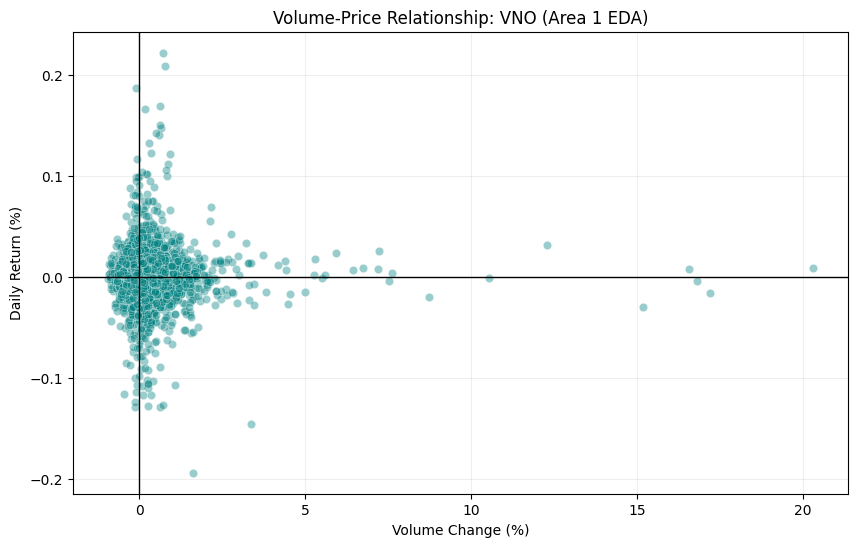

EDA Complete. VNO shows highest survival consistency.


In [13]:
# ============================================================
# AREA 1: ADVANCED EDA - Weekly Consistency & Survival Analysis
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
# Combining splits to cover the full 2000-2019 window
all_prices = pd.concat([prices_dev, prices_val])
all_prices['date'] = pd.to_datetime(all_prices['date']).dt.tz_localize(None)
eda_df = all_prices[(all_prices['date'] >= '2000-01-01') & (all_prices['date'] <= '2019-12-31')].copy()

def analyze_weekly_consistency(df, sl_pct=0.20):
    results = []
    # Grouping by ticker to analyze individual lifecycle
    for ticker, group in df.groupby('ticker'):
        group = group.sort_values('date')
        if len(group) < 52: continue # Skip tickers with less than a year of data
        
        # Initial stats
        start_price = group['close'].iloc[0]
        end_price = group['close'].iloc[-1]
        sl_threshold = start_price * (1 - sl_pct)
        
        # Resample to Weekly 'low' to check for stop-loss hits
        weekly_data = group.set_index('date').resample('W').agg({'low': 'min', 'volume': 'mean', 'close': 'last'})
        weekly_data = weekly_data.dropna()
        
        # Survival Logic: +1 if weekly low >= Stop Loss, -1 if weekly low < Stop Loss
        scores = np.where(weekly_data['low'] >= sl_threshold, 1, -1)
        
        results.append({
            'Ticker': ticker,
            'Price (2000)': round(start_price, 2),
            'Price (2019)': round(end_price, 2),
            'Consistency Score': scores.sum(),
            'Safety Ratio (%)': round((scores == 1).mean() * 100, 2),
            'Total Return (%)': round(((end_price / start_price) - 1) * 100, 2)
        })
    return pd.DataFrame(results)

# 2. Generate and Display the Consistency Table
survival_df = analyze_weekly_consistency(eda_df)
top_survivors = survival_df.sort_values('Consistency Score', ascending=False).head(40)

print("TOP 40 CONSISTENT SURVIVORS (2000-2019)")
print("Consistency Score = (Weeks Above 20% SL) - (Weeks Below 20% SL)")
display(top_survivors)

# 3. VISUALIZATION: Volume-Price Relationship Analysis
# We'll plot this for the #1 Most Consistent Ticker
top_ticker = top_survivors.iloc[0]['Ticker']
ticker_plot_data = eda_df[eda_df['ticker'] == top_ticker].copy()
ticker_plot_data['daily_return'] = ticker_plot_data['close'].pct_change()
ticker_plot_data['volume_change'] = ticker_plot_data['volume'].pct_change()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ticker_plot_data, x='volume_change', y='daily_return', alpha=0.4, color='teal')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title(f"Volume-Price Relationship: {top_ticker} (Area 1 EDA)")
plt.xlabel("Volume Change (%)")
plt.ylabel("Daily Return (%)")
plt.grid(True, alpha=0.2)
plt.show()

print(f"EDA Complete. {top_ticker} shows highest survival consistency.")

In [14]:
# ============================================================
# ADVANCED EDA: Top 20 Performers (2000-2019) with Price Points
# ============================================================
import pandas as pd
import numpy as np

def get_top_performers_with_prices(prices_dev_df, prices_val_df, n_top=20):
    print("Extracting 2000-2019 price points and calculating returns...")
    
    # 1. Combine datasets and normalize dates
    all_prices = pd.concat([prices_dev_df, prices_val_df])
    all_prices['date'] = pd.to_datetime(all_prices['date']).dt.tz_localize(None)
    
    # 2. Filter for the specific 2000-2019 window
    mask = (all_prices['date'].dt.year >= 2000) & (all_prices['date'].dt.year <= 2019)
    df_window = all_prices[mask].copy()
    
    # 3. Aggregate Performance per Ticker
    perf_data = []
    for ticker, group in df_window.groupby('ticker'):
        group = group.sort_values('date')
        if len(group) > 1:
            start_price = group['close'].iloc[0]
            start_date = group['date'].iloc[0].strftime('%Y-%m-%d')
            end_price = group['close'].iloc[-1]
            end_date = group['date'].iloc[-1].strftime('%Y-%m-%d')
            
            total_return = (end_price - start_price) / start_price
            
            perf_data.append({
                'ticker': ticker,
                'Start Date': start_date,
                'Price (2000)': round(start_price, 2),
                'End Date': end_date,
                'Price (2019)': round(end_price, 2),
                'Total Return': total_return
            })
            
    # 4. Sort and select top performers
    perf_df = pd.DataFrame(perf_data).sort_values('Total Return', ascending=False).head(n_top)
    
    # 5. Integrate Sector Mapping
    try:
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        sp500_table = pd.read_html(url, attrs={'id': 'constituents'})[0]
        sector_map = sp500_table.set_index('Symbol')['GICS Sector'].to_dict()
        perf_df['Sector'] = perf_df['ticker'].map(sector_map).fillna('Other')
    except:
        perf_df['Sector'] = 'Unknown'

    # 6. Formatting
    perf_df['Return (%)'] = perf_df['Total Return'].apply(lambda x: f"{x:,.1%}")
    
    cols = ['ticker', 'Sector', 'Start Date', 'Price (2000)', 'End Date', 'Price (2019)', 'Return (%)']
    return perf_df[cols].reset_index(drop=True)

# Execute the analysis
top_performer_prices = get_top_performers_with_prices(prices_dev, prices_val)
print("\nDETAILED PERFORMANCE: TOP 20 TICKERS (2000-2019)")
display(top_performer_prices)

Extracting 2000-2019 price points and calculating returns...

DETAILED PERFORMANCE: TOP 20 TICKERS (2000-2019)


,ticker,Sector,Start Date,Price (2000),End Date,Price (2019),Return (%)
0,MNST,Unknown,2000-01-03,0.04,2019-12-31,31.77,"70,633.7%"
1,ODFL,Unknown,2000-01-03,0.47,2019-12-31,61.55,"12,864.4%"
2,TPL,Unknown,2000-01-03,0.66,2019-12-31,78.46,"11,785.8%"
3,TSCO,Unknown,2000-01-03,0.16,2019-12-31,17.01,"10,380.1%"
4,AAPL,Unknown,2000-01-03,0.84,2019-12-31,70.79,"8,342.0%"
5,KMX,Unknown,2000-01-03,1.12,2019-12-31,87.67,"7,692.9%"
6,MA,Unknown,2006-05-25,4.17,2019-12-31,288.26,"6,806.4%"
7,NVDA,Unknown,2000-01-03,0.09,2019-12-31,5.86,"6,449.6%"
8,IDXX,Unknown,2000-01-03,4.02,2019-12-31,261.13,"6,402.8%"
9,ROST,Unknown,2000-01-03,1.70,2019-12-31,109.76,"6,353.7%"


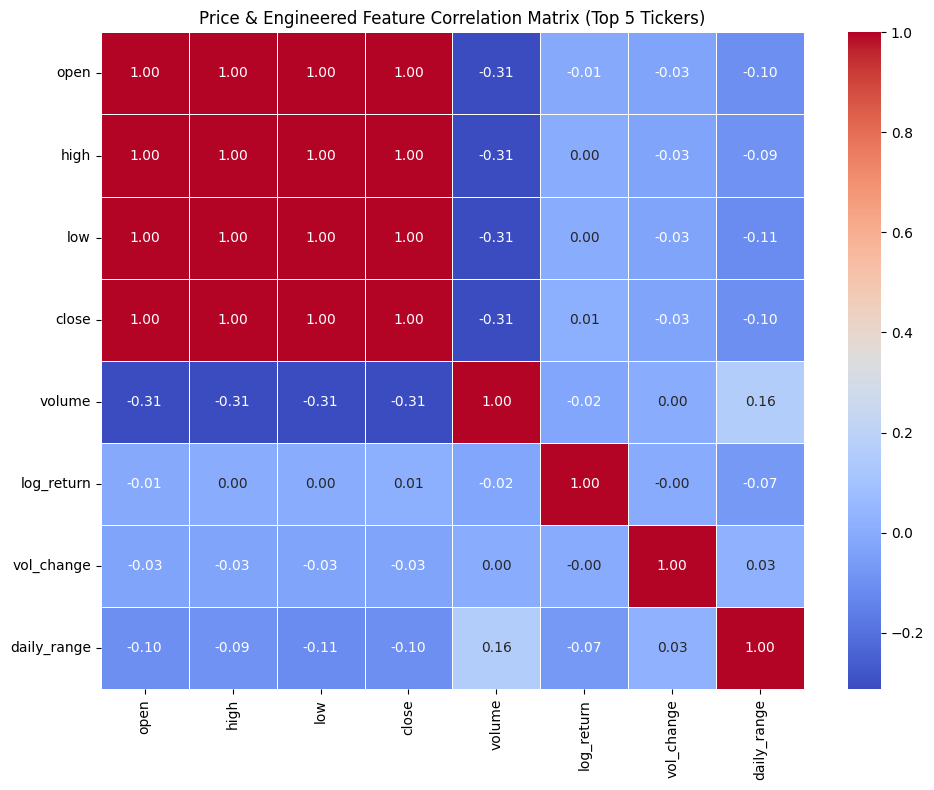

In [15]:
# ============================================================
# ADVANCED EDA: Feature Correlation Analysis (2000-2019)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_advanced_correlation(prices_df, n_tickers=5):
    # 1. Select top tickers by data points to ensure a robust correlation
    # FIX: Changed .n_index to .index
    top_tickers = prices_df['ticker'].value_counts().index[:n_tickers]
    df_sample = prices_df[prices_df['ticker'].isin(top_tickers)].copy()
    
    # Ensure data is sorted by ticker and date for correct shift operations
    df_sample = df_sample.sort_values(['ticker', 'date'])
    
    # 2. Engineering features for correlation
    # Log returns and volume changes help see movement relationships
    df_sample['log_return'] = df_sample.groupby('ticker')['close'].transform(lambda x: np.log(x / x.shift(1)))
    df_sample['vol_change'] = df_sample.groupby('ticker')['volume'].transform(lambda x: x.pct_change())
    df_sample['daily_range'] = (df_sample['high'] - df_sample['low']) / df_sample['close']
    
    # 3. Calculate Correlation Matrix
    # We drop NaN values created by shifting (log_return/vol_change)
    corr_cols = ['open', 'high', 'low', 'close', 'volume', 'log_return', 'vol_change', 'daily_range']
    corr_matrix = df_sample[corr_cols].dropna().corr()
    
    # 4. Plot Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Price & Engineered Feature Correlation Matrix (Top 5 Tickers)")
    plt.tight_layout()
    plt.show()

# Run the analysis on the dev split
plot_advanced_correlation(prices_dev)

In [16]:
# ============================================================
# AREA 4: FinBERT Sentiment Behavior Test
# ============================================================
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# 1. Load a sample transcript from your local file
# We'll take the first row of the dev set to test the "behavior"
try:
    # If the file is already loaded as 'earnings_dev' in a previous cell, we use that
    sample_row = earnings_dev.iloc[0] 
    ticker = sample_row['ticker']
    transcript = sample_row['transcript']
    date = sample_row['date']
except NameError:
    # Fallback if the dataframe isn't in memory yet
    temp_df = pd.read_parquet('earnings_dev.parquet').iloc[0:1]
    sample_row = temp_df.iloc[0]
    ticker = sample_row['ticker']
    transcript = sample_row['transcript']
    date = sample_row['date']

print(f"Testing FinBERT on {ticker} transcript from {date}")
print(f"Full transcript length: {len(transcript)} characters\n")

# 2. Load the FinBERT model and tokenizer locally
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    use_safetensors=True  # Force safetensors format to bypass torch version check
)

# 3. Process the text
# We truncate to 512 tokens as per BERT's architectural limit
inputs = tokenizer(transcript, return_tensors="pt", padding=True, truncation=True, max_length=512)

# 4. Perform Inference
with torch.no_grad():
    outputs = model(**inputs)
    # Convert 'logits' to probabilities (0.0 to 1.0)
    probs = F.softmax(outputs.logits, dim=-1).numpy()[0]

# 5. Interpret the Behavior
# FinBERT labels: 0 -> positive, 1 -> negative, 2 -> neutral
labels = ['Positive', 'Negative', 'Neutral']
results = {labels[i]: probs[i] for i in range(len(labels))}

print("-" * 30)
print("FINBERT SENTIMENT BREAKDOWN:")
for label, score in results.items():
    print(f"{label}: {score:.4f}")
print("-" * 30)

# Preview the text that FinBERT actually "saw" (the first ~300 words)
print("\nPreview of analyzed text (First 500 chars):")
print(f"\"{transcript[:500]}...\"")

Testing FinBERT on A transcript from 2006-02-13 14:45:00
Full transcript length: 73430 characters



Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11902.35it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


------------------------------
FINBERT SENTIMENT BREAKDOWN:
Positive: 0.0432
Negative: 0.0210
Neutral: 0.9359
------------------------------

Preview of analyzed text (First 500 chars):
"Agilent Technologies Incorporated (NYSE:A) :  Q1 2006 Earnings Release Conference Call   February 13, 2006
Operator: Good day, ladies and gentlemen and welcome to the Q1 2006 Agilent Technology Incorporated Earnings Conference and Analyst Meeting. My name is Jessie and I will be your coordinator for today’s call. At this time, all participants are in a listen-only mode and we will be conducting a question and answer session towards the end of this conference. As at any time during the call you r..."


In [17]:
# ============================================================
# CELL 13: Enhanced Strategy Implementation
# ============================================================
#
# IMPLEMENT YOUR ENHANCED STRATEGY HERE
#
# This is where you will implement improvements to the baseline strategy.
# Consider the five exploration areas:
#
# Area 1: Enhanced EDA
#   - Additional visualizations for insights (use Cell 12)
#
# Area 2: Data Quality & Cleaning (override clean_data)
#   - Forward-fill missing prices
#   - Filter outliers
#   - Remove tickers with insufficient data
#
# Area 3: More Technical Indicators (override calculate_analytics)
#   - RSI: 14-period relative strength index
#   - MACD: Moving Average Convergence Divergence
#   - Bollinger Bands: 20-day +-2 standard deviations
#
# Area 4: Enhanced LLM Analysis (override llm_analysis)
#   - Use more text from transcripts (4000+ characters)
#   - Calculate sentiment strength (positive - negative scores)
#   - Weight decisions by confidence levels
#
# Area 5: Smarter Decision Logic (override make_decision)
#   - Multi-signal confirmation (require 2+ signals)
#   - Position sizing based on signal strength
#   - Stop-loss / take-profit mechanisms
#   - Risk management controls
#
# Expected Improvements:
#   - Higher Total Return (target: >50%)
#   - Higher Sharpe Ratio (target: >1.0)
#   - Lower Max Drawdown (target: <30%)
#   - Lower Volatility (target: <40%)
#   - Higher Win Rate (target: >40%)
import pandas as pd
import numpy as np
import time
import warnings
from datetime import timedelta
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

print("\n" + "="*70)
print("ENHANCED STRATEGY")
print("="*70)

class EnhancedStrategy(BaseStrategy):
    def __init__(self, finbert_pipeline=None):
        """Initialize your enhanced strategy."""
        # Initialize any strategy-specific attributes here
        # Example: self.entry_dates = {}  # For holding period tracking
        super().__init__(finbert_pipeline)
        # For Area 5: Tracking the "Weekly Ratchet" for each ticker
        self.highest_price_seen = {}

    def clean_data(self, prices_df, earnings_df):
        """
        Override to implement enhanced data cleaning.

        Ideas:
        - Forward-fill missing prices by ticker
        - Filter tickers with insufficient data
        - Remove outliers
        """
        # 1. Sort and Forward-fill to maintain weekly continuity
        prices_df = prices_df.sort_values(['ticker', 'date'])
        prices_df[['open', 'high', 'low', 'close']] = prices_df.groupby('ticker')[['open', 'high', 'low', 'close']].ffill()

        # 2. Minimum Price Filter ($5) to avoid 'penny stock' volatility
        prices_df = prices_df[prices_df['close'] >= 5.0]

        # 3. History Filter: Ensure 200 days exist for stable EMA-200 calculation
        ticker_counts = prices_df.groupby('ticker').size()
        valid_tickers = ticker_counts[ticker_counts >= 200].index
        prices_df = prices_df[prices_df['ticker'].isin(valid_tickers)]
        return prices_df, earnings_df

    def calculate_analytics(self, prices_df):
        """
        Override to compute additional technical indicators.

        Ideas:
        - RSI: 14-period relative strength index
        - MACD: EMA-12, EMA-26, signal line
        - Bollinger Bands: 20-day +-2 std dev

        Consider: How can you parallelize or optimize these computations
        to handle 400+ tickers efficiently?
        """
        """Area 3: Multi-Layered Technical Indicators."""
        # Using vectorized operations for speed (crucial for 400+ tickers)
        # Structural Trend
        prices_df['ema_200'] = prices_df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=200, adjust=False).mean())
        prices_df['ema_50'] = prices_df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=50, adjust=False).mean())

        # RSI (14-period)
        prices_df['rsi'] = prices_df.groupby('ticker')['close'].transform(self._calculate_rsi, window=14)

        #MACD (12, 26, 9)
        prices_df['ema_12'] = prices_df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
        prices_df['ema_26'] = prices_df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
        prices_df['macd'] = prices_df['ema_12'] - prices_df['ema_26']
        prices_df['signal_line'] = prices_df.groupby('ticker')['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
        prices_df['macd_hist'] = prices_df['macd'] - prices_df['signal_line']

        # Pace Picking up (Histogram Slope)
        prices_df['hist_prev'] = prices_df.groupby('ticker')['macd_hist'].shift(1)
        prices_df['pace_improving'] = prices_df['macd_hist'] > prices_df['hist_prev']

        # Convert dates to strings for comparison (required by TradingSimulation)
        prices_df['date'] = prices_df['date'].dt.strftime('%Y-%m-%d')
        
        return prices_df

    def _calculate_rsi(self, prices, window):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    def llm_analysis(self, ticker, transcript, date):
        """
        Override to enhance NLP analysis.

        Ideas:
        - Use more text (4000+ chars)
        - Calculate sentiment strength (positive - negative)
        - Weight decisions by confidence
        """
        """Area 4: Enhanced NLP Analysis with SafeTensors."""
        # Use the first 4000 characters to capture CEO's speech beyond the operator intro
        if not transcript or len(transcript) < 100:
            return None  # No transcript this week — don't penalise entry
        
        try:
            sentiment = self.finbert_pipeline(transcript[:4000], truncation=True)[0]
            score_map = {'positive': 1.0, 'neutral': 0.5, 'negative': 0.0}
            return score_map.get(sentiment['label'], 0.5)
        except Exception as e:
            print(f"Error occurred while analyzing sentiment for {ticker}: {e}")
            return None  # On error, don't block the trade

    def make_decision(self, ticker, date, transcript, portfolio_state, analytics):
        """
        Override to implement smarter trading logic.

        Ideas:
        - Combine multiple indicators (RSI, MACD, sentiment)
        - Require 2+ signals for entry/exit
        - Add stop-loss / take-profit
        - Implement minimum holding period
        """
        """Area 5: Smarter Decision Logic - Structural Rebound."""
        curr_price = analytics.get('close', 0)
        if not curr_price:
            return 'HOLD'

        # --- EXIT LOGIC---
        if ticker in portfolio_state['positions']:
            #Update Weekly Ratchet
            self.highest_price_seen[ticker] = max(self.highest_price_seen.get(ticker, 0), curr_price)
            
            # 1. Trailing Stop-Loss (-15% from Friday Peak)
            stop_price = self.highest_price_seen[ticker] * 0.85
            if curr_price < stop_price:
                del self.highest_price_seen[ticker]
                return 'SELL'
            
            # 2. Momentum Decay (Histogram turned down)
            if not analytics.get('pace_improving', True):
                del self.highest_price_seen[ticker]
                return 'SELL'
        
        # --- ENTRY LOGIC ---
        # 1. Structural Trend: Price above EMA-200 and EMA-50
        structural_ok = curr_price > analytics.get('ema_50', float('inf')) and curr_price > analytics.get('ema_200', float('inf'))

        # 2. Momentum Reversal: RSI < 55 (not overbought) and MACD Histogram is rising
        momentum_rebound = analytics.get('rsi', 100) < 45 and analytics.get('pace_improving', False)

        # 3. Sentiment Confirmation: only block if sentiment is explicitly negative
        sentiment_score = self.llm_analysis(ticker, transcript, date)
        sentiment_ok = sentiment_score is None or sentiment_score >= 0.5

        if structural_ok and momentum_rebound and sentiment_ok:
            # Initialize the highest price seen for this ticker
            self.highest_price_seen[ticker] = curr_price
            return 'BUY'
        
        return 'HOLD'
    '''
        Note: While this implementation focuses on overriding the core strategy methods
        (clean_data, calculate_analytics, llm_analysis, make_decision), you may optionally
        override other base class methods such as evaluate() to implement custom evaluation
        logic or you can add new functions to this class, provided that all modifications
        maintain backward compatibility and execute without runtime errors.
    '''

print("EnhancedStrategy class loaded (implement methods above to improve strategy)")


ENHANCED STRATEGY
EnhancedStrategy class loaded (implement methods above to improve strategy)



ENHANCED STRATEGY EVALUATION (Development)

[DEV SPLIT - For Development]
Loading DEV split data...
Cleaning and preprocessing data...
Data ready: 1,242,868 price records
Running evaluation...
Running backtest simulation...
Return: 165.52%
Sharpe Ratio: 1.50
Max Drawdown: -18.52%
Win Rate: 49.4%
Volatility: 18.61%
Total Trades: 12,596

DEVELOPMENT TIPS
• Iterate on your strategy implementation in Cell 13
• Re-run this cell to test changes on dev split
• Compare against baseline dev performance (run baseline on dev if needed)
• When satisfied, run on val split for final reporting


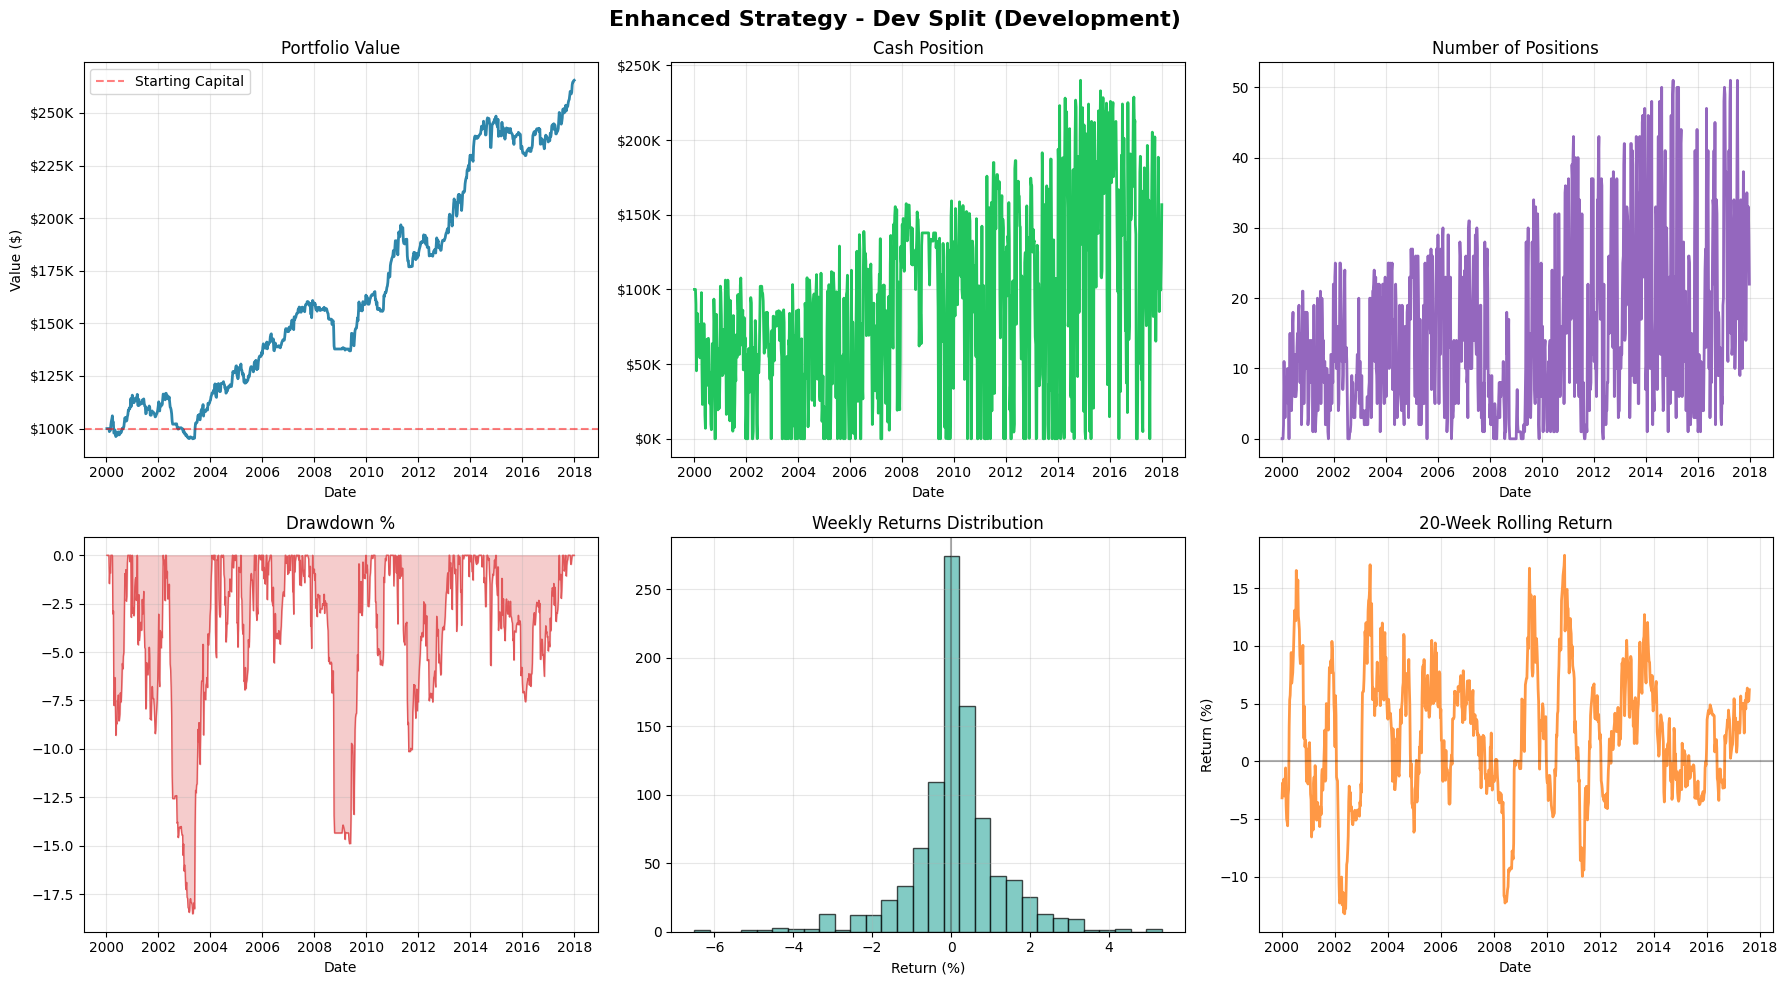


FINAL PERFORMANCE

[VAL SPLIT - Final Performance]
Loading VAL split data...
Cleaning and preprocessing data...
Data ready: 596,741 price records
Running evaluation...
Running backtest simulation...
Return: 55.80%
Sharpe Ratio: 1.51
Max Drawdown: -12.35%
Win Rate: 48.7%
Volatility: 21.94%
Total Trades: 4,777


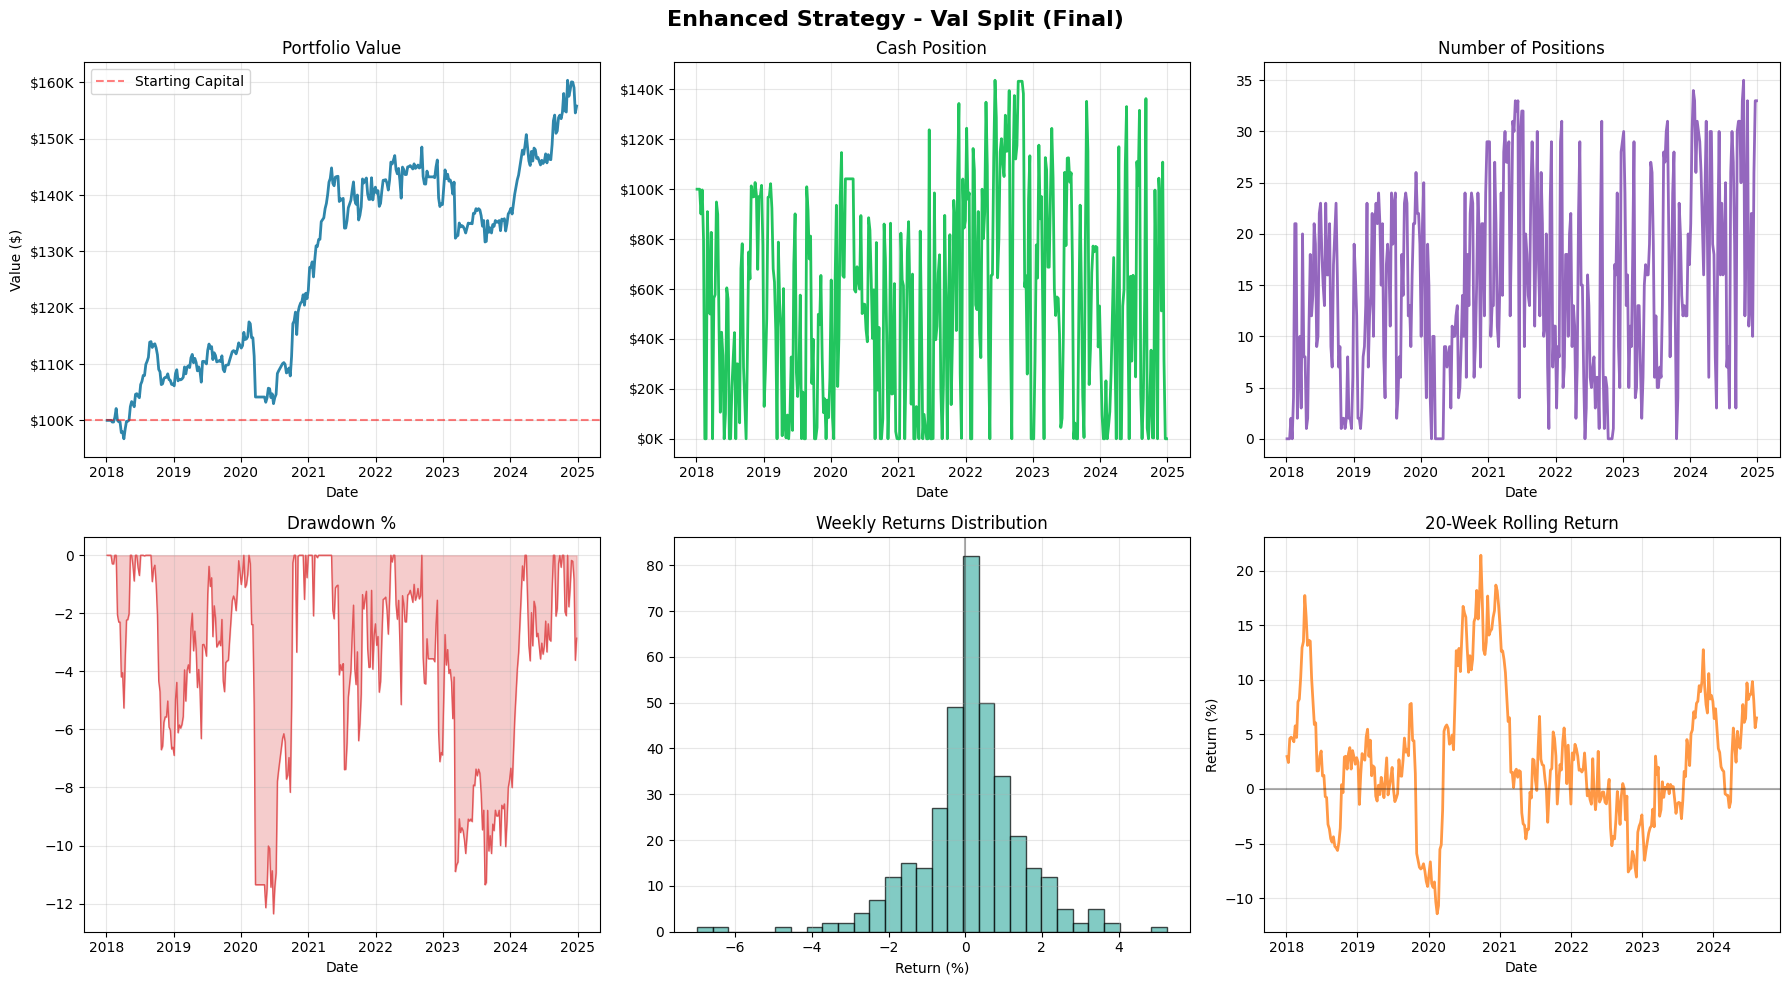

In [18]:
# ============================================================
# CELL 14: Enhanced Strategy Evaluation
# ============================================================

# Evaluate your enhanced strategy on the DEV split during development.

# IMPORTANT: Split Usage
# ----------------------
# - **Dev Split**: Use THIS split for development and hyperparameter tuning
#   - Iterate on your strategy implementation
#   - Test different RSI periods, stop-loss levels, signal thresholds
#   - Compare against baseline performance on dev

# - **Val Split**: Reserve for FINAL performance reporting only
#   - Do not evaluate on val until your strategy is finalized
#   - This is your "test" set for reporting final metrics

# UNCOMMENT THE CODE BELOW ONCE YOU'VE IMPLEMENTED YOUR STRATEGY IN CELL 13

print("\n" + "="*70)
print("ENHANCED STRATEGY EVALUATION (Development)")
print("="*70)

# Create enhanced strategy instance
strategy_cls = globals().get("EnhancedStrategy")
if not isinstance(strategy_cls, type) or not issubclass(strategy_cls, BaseStrategy):
    strategy_cls = BaseStrategy
if strategy_cls is BaseStrategy:
    print("Warning: EnhancedStrategy is not defined. Using BaseStrategy fallback. Run Cell 13 first.")
enhanced = strategy_cls(finbert_pipeline)

# Evaluate on DEV split (for development/tuning)
print("\n[DEV SPLIT - For Development]")
results_enhanced_dev = run_evaluation(enhanced, split='dev')

# Calculate metrics
metrics_enhanced_dev = calculate_metrics(results_enhanced_dev)
ENHANCED_METRICS_DEV = {
    'return': metrics_enhanced_dev['total_return'],
    'sharpe': metrics_enhanced_dev['sharpe_ratio'],
    'drawdown': metrics_enhanced_dev['max_drawdown'],
    'win_rate': metrics_enhanced_dev['win_rate'],
    'volatility': metrics_enhanced_dev['volatility'],
    'trades': metrics_enhanced_dev['num_trades']
}

# Display results
print(f"Return: {ENHANCED_METRICS_DEV['return']:.2%}")
print(f"Sharpe Ratio: {ENHANCED_METRICS_DEV['sharpe']:.2f}")
print(f"Max Drawdown: {ENHANCED_METRICS_DEV['drawdown']:.2%}")
print(f"Win Rate: {ENHANCED_METRICS_DEV['win_rate']:.1%}")
print(f"Volatility: {ENHANCED_METRICS_DEV['volatility']:.2%}")
print(f"Total Trades: {ENHANCED_METRICS_DEV['trades']:,}")

print("\n" + "="*70)
print("DEVELOPMENT TIPS")
print("="*70)
print("• Iterate on your strategy implementation in Cell 13")
print("• Re-run this cell to test changes on dev split")
print("• Compare against baseline dev performance (run baseline on dev if needed)")
print("• When satisfied, run on val split for final reporting")
print("="*70)

# Visualization
plot_results(results_enhanced_dev, metrics_enhanced_dev, title="Enhanced Strategy - Dev Split (Development)")

# ============================================================
# Val Split Evaluation
# ============================================================
# ONLY uncomment when your strategy is finalized and ready for final testing

print("\n" + "="*70)
print("FINAL PERFORMANCE")
print("="*70)

print("\n[VAL SPLIT - Final Performance]")
results_enhanced_val = run_evaluation(enhanced, split='val')

metrics_enhanced_val = calculate_metrics(results_enhanced_val)
ENHANCED_METRICS_VAL = {
    'return': metrics_enhanced_val['total_return'],
    'sharpe': metrics_enhanced_val['sharpe_ratio'],
    'drawdown': metrics_enhanced_val['max_drawdown'],
    'win_rate': metrics_enhanced_val['win_rate'],
    'volatility': metrics_enhanced_val['volatility'],
    'trades': metrics_enhanced_val['num_trades']
}

print(f"Return: {ENHANCED_METRICS_VAL['return']:.2%}")
print(f"Sharpe Ratio: {ENHANCED_METRICS_VAL['sharpe']:.2f}")
print(f"Max Drawdown: {ENHANCED_METRICS_VAL['drawdown']:.2%}")
print(f"Win Rate: {ENHANCED_METRICS_VAL['win_rate']:.1%}")
print(f"Volatility: {ENHANCED_METRICS_VAL['volatility']:.2%}")
print(f"Total Trades: {ENHANCED_METRICS_VAL['trades']:,}")

plot_results(results_enhanced_val, metrics_enhanced_val, title="Enhanced Strategy - Val Split (Final)")

In [21]:
# Trade activity audit + export (CSV/JSON)
# Uses existing objects from previous cells: results_* and prices_dev/prices_val

# 1) Pick which backtest result to analyze
RESULT_VAR = "results_enhanced_val"  # change if needed (e.g., "results_enhanced_dev", "results_baseline_val")
OUTPUT_PREFIX = "trade_audit_enhanced_val"  # output file prefix

if RESULT_VAR not in globals():
    # Fallback to first available result object
    for candidate in ["results_enhanced_val", "results_enhanced_dev", "results_baseline_val", "results_baseline_dev"]:
        if candidate in globals():
            RESULT_VAR = candidate
            OUTPUT_PREFIX = f"trade_audit_{candidate}"
            break

if RESULT_VAR not in globals():
    raise ValueError("No results_* variable found. Run an evaluation cell first.")

results_obj = globals()[RESULT_VAR]

# 2) Pick matching price dataframe
if "val" in RESULT_VAR and "prices_val" in globals():
    prices_source = prices_val.copy()
elif "dev" in RESULT_VAR and "prices_dev" in globals():
    prices_source = prices_dev.copy()
else:
    prices_source = pd.concat([prices_dev, prices_val], ignore_index=True).copy()

# 3) Build trade report
trades_df = pd.DataFrame(results_obj.get("trades", []))
if trades_df.empty:
    print(f"No trades found in {RESULT_VAR}.")
else:
    trades_df = trades_df.copy()
    trades_df["date"] = pd.to_datetime(trades_df["date"])
    trades_df = trades_df.sort_values(["ticker", "date"]).reset_index(drop=True)

    px = prices_source[["ticker", "date", "volume"]].copy()
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values(["ticker", "date"]).reset_index(drop=True)

    # Merge nearest available market volume at or before trade date
    # Convert both date columns to the same timezone-naive format
    trades_df["date"] = pd.to_datetime(trades_df["date"]).dt.tz_localize(None)
    px["date"] = pd.to_datetime(px["date"]).dt.tz_localize(None)
    
    # Ensure both are in nanosecond precision
    trades_df["date"] = trades_df["date"].astype('datetime64[ns]')
    px["date"] = px["date"].astype('datetime64[ns]')
    
    merged = pd.merge_asof(
        trades_df.sort_values("date"),
        px.sort_values("date"),
        on="date",
        by="ticker",
        direction="backward"
    ).sort_values(["ticker", "date"]).reset_index(drop=True)

    # Profit/Loss % for SELL rows (matched to latest BUY per ticker)
    latest_buy_price = {}
    pnl_pct = []

    for row in merged.itertuples(index=False):
        tkr = row.ticker
        if row.action == "BUY":
            latest_buy_price[tkr] = row.price
            pnl_pct.append(np.nan)
        elif row.action == "SELL":
            bp = latest_buy_price.get(tkr, np.nan)
            if pd.notna(bp) and bp != 0:
                pnl_pct.append((row.price - bp) / bp * 100.0)
            else:
                pnl_pct.append(np.nan)
            latest_buy_price.pop(tkr, None)
        else:
            pnl_pct.append(np.nan)

    merged["profit_loss_pct"] = pnl_pct
    merged["signal"] = merged["action"].map({"BUY": "BOUGHT", "SELL": "SOLD"}).fillna(merged["action"])
    merged["outcome"] = np.where(
        merged["profit_loss_pct"] > 0, "PROFIT",
        np.where(merged["profit_loss_pct"] < 0, "LOSS", "")
    )

    report = merged[[
        "date", "ticker", "price", "volume", "signal", "profit_loss_pct", "outcome", "shares", "value"
    ]].copy()

    report["date"] = report["date"].dt.strftime("%Y-%m-%d")
    report["profit_loss_pct"] = report["profit_loss_pct"].round(2)

    # 4) Export
    csv_path = f"{OUTPUT_PREFIX}.csv"
    json_path = f"{OUTPUT_PREFIX}.json"

    report.to_csv(csv_path, index=False)
    report.to_json(json_path, orient="records", indent=2)

    print(f"Report source: {RESULT_VAR}")
    print(f"Rows: {len(report):,}")
    print(f"Saved CSV:  {csv_path}")
    print(f"Saved JSON: {json_path}")

    display(report.head(200))

Report source: results_enhanced_val
Rows: 4,777
Saved CSV:  trade_audit_enhanced_val.csv
Saved JSON: trade_audit_enhanced_val.json


,date,ticker,price,volume,signal,profit_loss_pct,outcome,shares,value
0,2018-02-16,A,67.783508,2887100,BOUGHT,NaN,,73,4948.196106
1,2018-02-23,A,66.587395,4227000,SOLD,-1.76,LOSS,73,4860.879814
2,2019-05-03,A,75.524002,1303200,BOUGHT,NaN,,66,4984.584137
3,2019-05-10,A,73.438011,2849800,SOLD,-2.76,LOSS,66,4846.908737
4,2020-06-19,A,85.279655,1784700,BOUGHT,NaN,,58,4946.220016
...,...,...,...,...,...,...,...,...,...
195,2019-12-06,AMAT,53.481247,6033500,BOUGHT,NaN,,93,4973.755966
196,2019-12-27,AMAT,57.799419,3314500,SOLD,8.07,PROFIT,93,5375.346004
197,2020-08-28,AMAT,60.220009,5206000,BOUGHT,NaN,,83,4998.260735
198,2020-09-04,AMAT,58.205364,14688100,SOLD,-3.35,LOSS,83,4831.045231


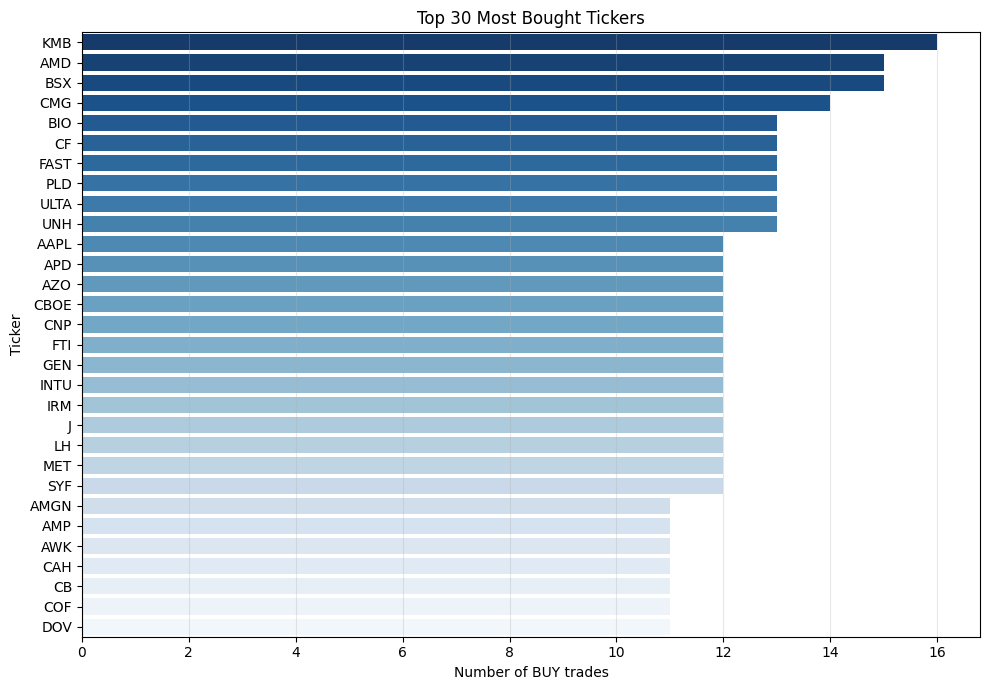

,buy_count
ticker,
KMB,16
AMD,15
BSX,15
CMG,14
BIO,13
CF,13
FAST,13
PLD,13
ULTA,13


In [25]:
# Frequency plot: most bought tickers
top_n = 30

most_bought = (
    trades_df.loc[trades_df["action"] == "BUY", "ticker"]
    .value_counts()
    .head(top_n)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=most_bought.values, y=most_bought.index, palette="Blues_r")
plt.title(f"Top {top_n} Most Bought Tickers")
plt.xlabel("Number of BUY trades")
plt.ylabel("Ticker")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(most_bought.rename("buy_count").to_frame())

In [ ]:
# Top 20 profitable tickers and top 20 losing tickers based on realized trade P&L

trade_pairs = trades_df.copy()
trade_pairs["date"] = pd.to_datetime(trade_pairs["date"])
trade_pairs = trade_pairs.sort_values(["ticker", "date"]).reset_index(drop=True)

latest_buy = {}
matched_trades = []

for row in trade_pairs.itertuples(index=False):
    if row.action == "BUY":
        latest_buy[row.ticker] = {
            "buy_date": row.date,
            "buy_price": row.price,
            "shares": row.shares,
            "buy_value": row.value
        }
    elif row.action == "SELL" and row.ticker in latest_buy:
        buy = latest_buy.pop(row.ticker)
        pnl_value = row.value - buy["buy_value"]
        pnl_pct = (row.price - buy["buy_price"]) / buy["buy_price"] * 100 if buy["buy_price"] != 0 else np.nan

        matched_trades.append({
            "ticker": row.ticker,
            "buy_date": buy["buy_date"],
            "sell_date": row.date,
            "shares": row.shares,
            "buy_price": buy["buy_price"],
            "sell_price": row.price,
            "buy_value": buy["buy_value"],
            "sell_value": row.value,
            "pnl_value": pnl_value,
            "pnl_pct": pnl_pct
        })

matched_trades_df = pd.DataFrame(matched_trades)

ticker_pnl_summary = (
    matched_trades_df.groupby("ticker", as_index=False)
    .agg(
        total_pnl=("pnl_value", "sum"),
        avg_pnl_pct=("pnl_pct", "mean"),
        winning_trades=("pnl_value", lambda x: (x > 0).sum()),
        losing_trades=("pnl_value", lambda x: (x < 0).sum()),
        total_round_trips=("ticker", "size")
    )
    .sort_values("total_pnl", ascending=False)
    .reset_index(drop=True)
)

top_20_profitable_tickers = ticker_pnl_summary.head(20).copy()
top_20_loss_tickers = ticker_pnl_summary.sort_values("total_pnl", ascending=True).head(20).copy()

print("TOP 20 PROFITABLE TICKERS")
display(top_20_profitable_tickers.style.format({
    "total_pnl": "${:,.2f}",
    "avg_pnl_pct": "{:.2f}%"
}))

print("TOP 20 LOSING TICKERS")
display(top_20_loss_tickers.style.format({
    "total_pnl": "${:,.2f}",
    "avg_pnl_pct": "{:.2f}%"
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    data=top_20_profitable_tickers.sort_values("total_pnl", ascending=True),
    x="total_pnl", y="ticker", ax=axes[0], palette="Greens_r"
)
axes[0].set_title("Top 20 Profitable Tickers")
axes[0].set_xlabel("Total Realized P&L ($)")
axes[0].set_ylabel("Ticker")
axes[0].grid(axis="x", alpha=0.3)

sns.barplot(
    data=top_20_loss_tickers.sort_values("total_pnl", ascending=False),
    x="total_pnl", y="ticker", ax=axes[1], palette="Reds_r"
)
axes[1].set_title("Top 20 Losing Tickers")
axes[1].set_xlabel("Total Realized P&L ($)")
axes[1].set_ylabel("Ticker")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()